### 1. Вибір датасету та Data Cleaning
Згідно з вимогами лабораторної роботи, було обрано датасет **Automobile** з репозиторію UCI Machine Learning. Цей набір даних відповідає всім критеріям:
- Є багатовимірним (Multivariate).
- Містить категоріальні, цілочисельні та дійсні атрибути.
- Має понад 2 числові атрибути.
- Містить пропущені значення (позначені символом `?`).

У наступному блоці коду реалізовано завантаження даних за прямим посиланням та виконано очищення даних (Data Cleaning): заміна знаків питання на `NaN`, конвертація типів даних, видалення критичних пропусків та заповнення інших пропусків медіанними значеннями (для числових даних) та модою (для категоріальних).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"

headers = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration",
           "num-of-doors", "body-style", "drive-wheels", "engine-location",
           "wheel-base", "length", "width", "height", "curb-weight", "engine-type",
           "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
           "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"]

df = pd.read_csv(url, names=headers)

df.replace("?", np.nan, inplace=True)

numeric_cols = ["normalized-losses", "bore", "stroke", "horsepower", "peak-rpm", "price"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

df.dropna(subset=['price'], inplace=True)

for col in ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm']:
    df[col] = df[col].fillna(df[col].median())

df['num-of-doors'] = df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])

print("Загальна кількість пропусків після Data Cleaning:", df.isnull().sum().sum())
display(df.head())

Загальна кількість пропусків після Data Cleaning: 0


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,115.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


### 2. Графік залежності двох числових атрибутів
Згідно з завданням, необхідно побудувати графік залежності одного integer/real атрибута від іншого. 

Для цього було обрано атрибути **об'єм двигуна (engine-size)** та **ціна (price)**. Побудовано Scatter Plot з лінією регресії (тренду), що наочно демонструє позитивну кореляцію між цими показниками. Також додано анотацію для найдорожчого автомобіля у вибірці.

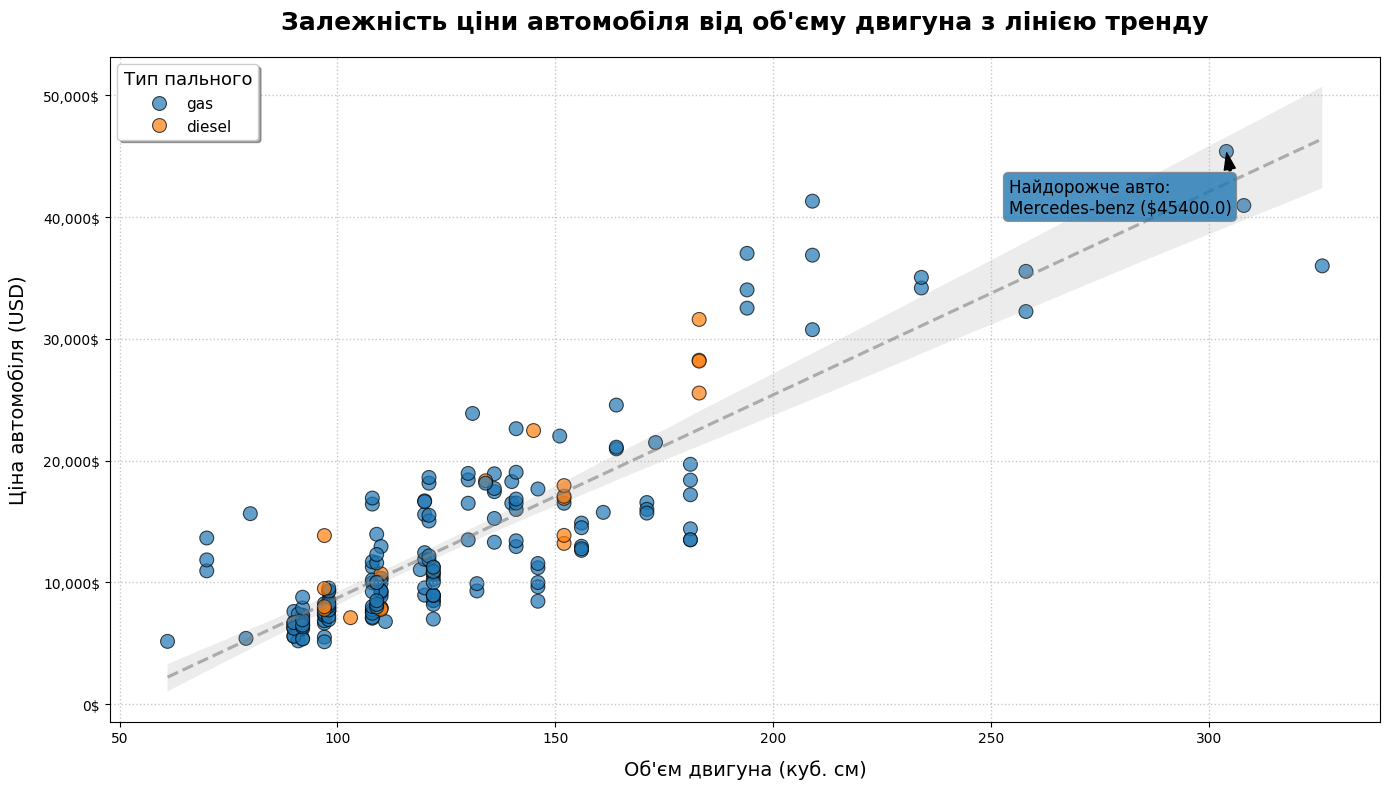

In [3]:
fig, ax = plt.subplots(figsize=(14, 8))

sns.scatterplot(data=df, x='engine-size', y='price', 
                hue='fuel-type', palette=['#1f77b4', '#ff7f0e'], 
                s=100, alpha=0.7, edgecolor='black', ax=ax)

sns.regplot(data=df, x='engine-size', y='price', 
            scatter=False, color='gray', line_kws={"linestyle": "--", "alpha": 0.6}, ax=ax)

max_price_idx = df['price'].idxmax()
max_price_row = df.loc[max_price_idx]

ax.annotate(f"Найдорожче авто:\n{max_price_row['make'].capitalize()} (${max_price_row['price']})",
            xy=(max_price_row['engine-size'], max_price_row['price']), 
            xytext=(max_price_row['engine-size'] - 50, max_price_row['price'] - 5000),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
            fontsize=12, backgroundcolor='white', bbox=dict(boxstyle="round,pad=0.3", edgecolor="gray", alpha=0.8))

ax.set_title("Залежність ціни автомобіля від об'єму двигуна з лінією тренду", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Об'єм двигуна (куб. см)", fontsize=14, labelpad=10)
ax.set_ylabel("Ціна автомобіля (USD)", fontsize=14, labelpad=10)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}$".format(int(x))))

ax.grid(True, linestyle=':', linewidth=1, alpha=0.7)
ax.legend(title="Тип пального", title_fontsize='13', fontsize='11', loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

### 3. Гістограма з 5 діапазонами
Виконуючи вимогу щодо побудови гістограми, розбитої рівно на 5 діапазонів, було проаналізовано атрибут **потужність (horsepower)**. 

Для більшої інформативності на гістограму накладено криву щільності розподілу (KDE), а також додано статистичний блок, який відображає середнє значення, медіану, мінімум, максимум та стандартне відхилення.

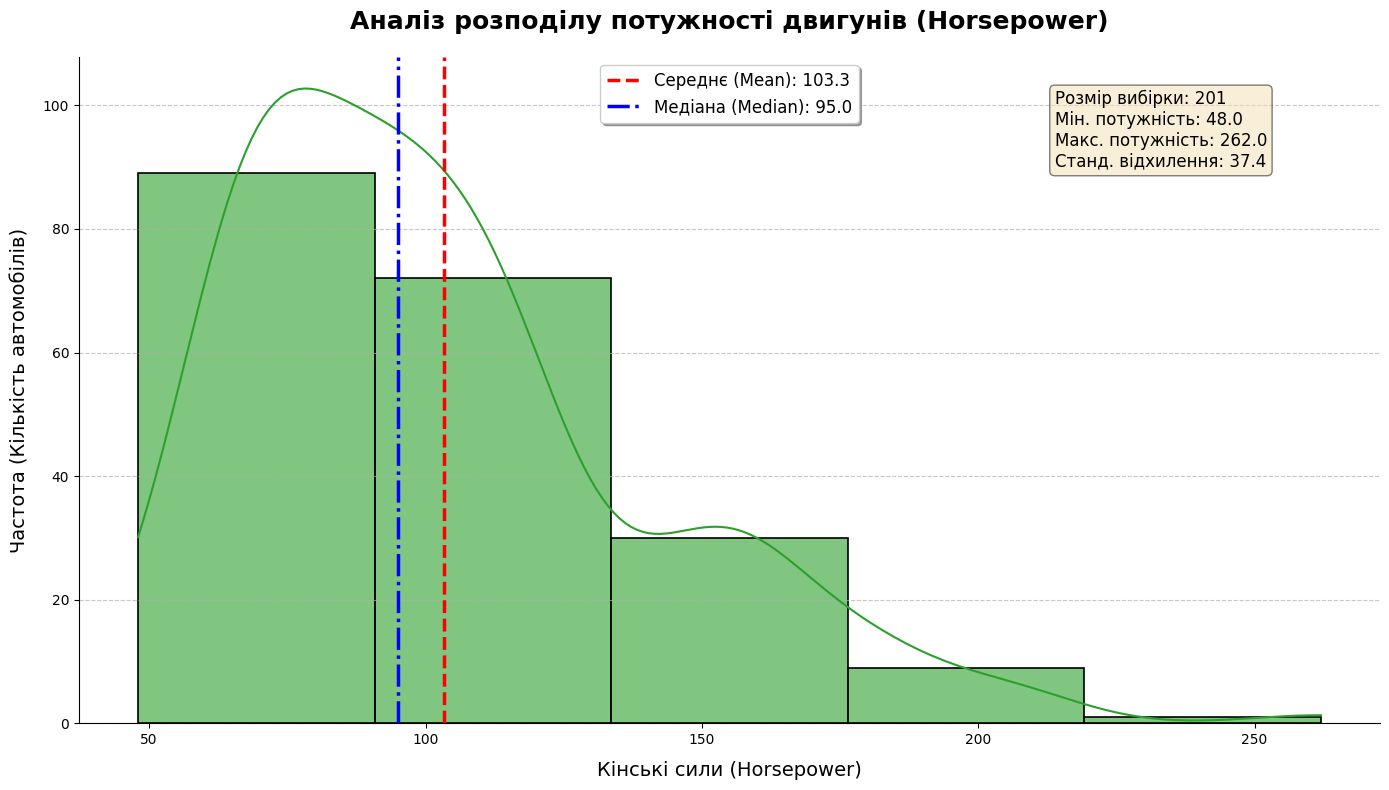

In [4]:
fig, ax = plt.subplots(figsize=(14, 8))

sns.histplot(data=df, x='horsepower', bins=5, kde=True, 
             color='#2ca02c', edgecolor='black', linewidth=1.2, alpha=0.6, ax=ax)

mean_hp = df['horsepower'].mean()
median_hp = df['horsepower'].median()

ax.axvline(mean_hp, color='red', linestyle='--', linewidth=2.5, label=f'Середнє (Mean): {mean_hp:.1f}')
ax.axvline(median_hp, color='blue', linestyle='-.', linewidth=2.5, label=f'Медіана (Median): {median_hp:.1f}')

stats_text = (f"Розмір вибірки: {len(df)}\n"
              f"Мін. потужність: {df['horsepower'].min()}\n"
              f"Макс. потужність: {df['horsepower'].max()}\n"
              f"Станд. відхилення: {df['horsepower'].std():.1f}")

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.75, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

ax.set_title("Аналіз розподілу потужності двигунів (Horsepower)", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Кінські сили (Horsepower)", fontsize=14, labelpad=10)
ax.set_ylabel("Частота (Кількість автомобілів)", fontsize=14, labelpad=10)

ax.legend(fontsize='12', loc='upper center', framealpha=1, shadow=True)
ax.grid(axis='y', linestyle='--', alpha=0.7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 4. Багатовимірна візуалізація (Multidimensional Data)
На основі підходів, описаних у статті про багатовимірну візуалізацію (Medium), побудовано графік, що відображає одразу 4 виміри на одній площині:
1. Осі X та Y (кількісні): Вага авто та витрата пального в місті.
2. Колір (категоріальний): Тип приводу (hue).
3. Розмір точки (кількісний): Об'єм двигуна (size).

Такий підхід дозволяє знаходити складні взаємозв'язки. Додатково додано автоматичний пошук та маркування найбільш економічного автомобіля.

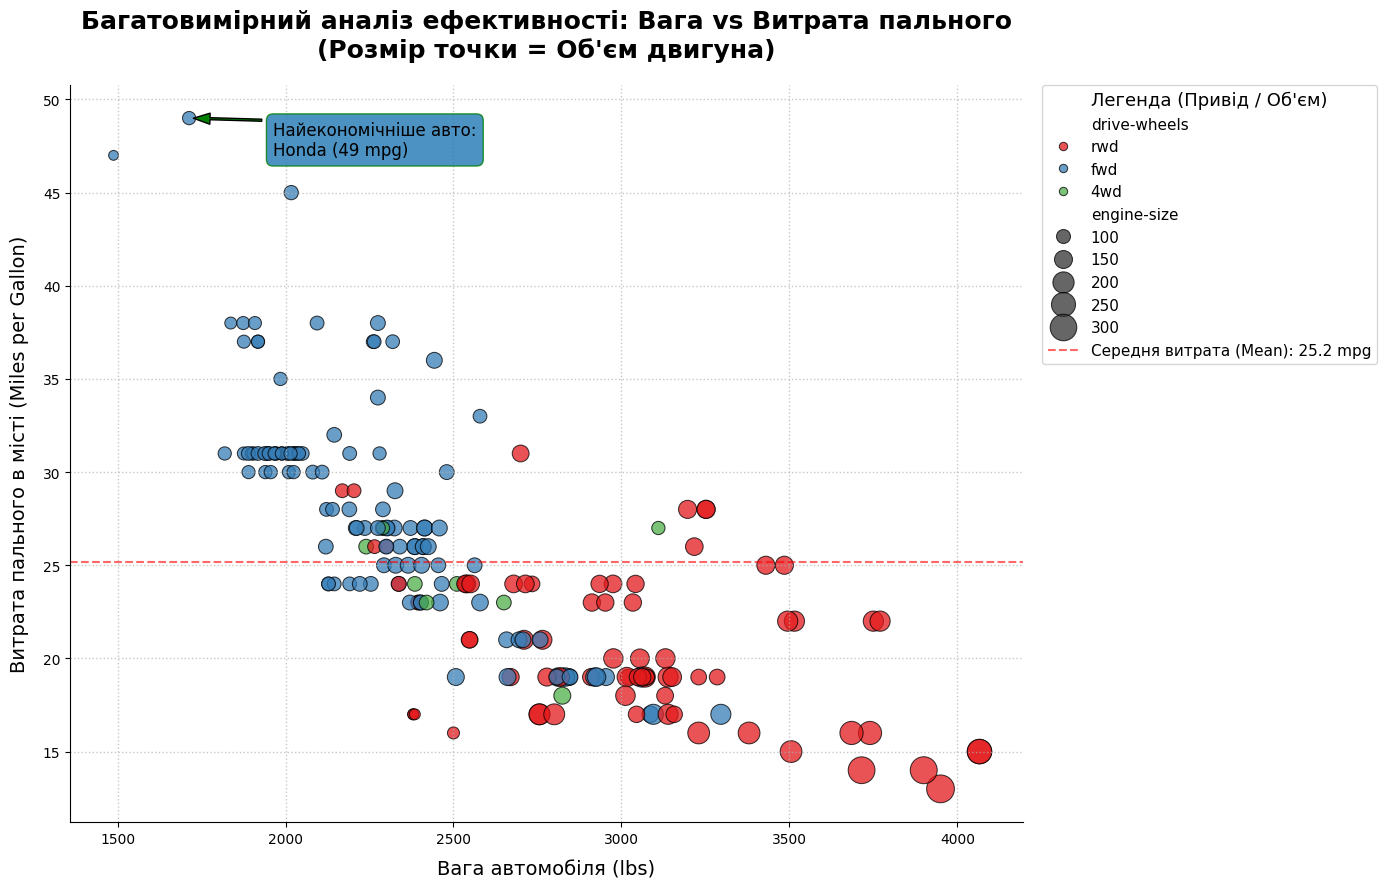

In [5]:
fig, ax = plt.subplots(figsize=(14, 9))

scatter = sns.scatterplot(data=df, x='curb-weight', y='city-mpg', 
                          hue='drive-wheels', size='engine-size', 
                          sizes=(50, 400), alpha=0.75, palette='Set1', 
                          edgecolor='black', ax=ax)

mean_mpg = df['city-mpg'].mean()
ax.axhline(mean_mpg, color='red', linestyle='--', alpha=0.6, 
           label=f'Середня витрата (Mean): {mean_mpg:.1f} mpg')

best_mpg_idx = df['city-mpg'].idxmax()
best_car = df.loc[best_mpg_idx]

ax.annotate(f"Найекономічніше авто:\n{best_car['make'].capitalize()} ({best_car['city-mpg']} mpg)",
            xy=(best_car['curb-weight'], best_car['city-mpg']), 
            xytext=(best_car['curb-weight'] + 250, best_car['city-mpg'] - 2),
            arrowprops=dict(facecolor='green', shrink=0.05, width=1.5, headwidth=8),
            fontsize=12, backgroundcolor='#e6ffe6', 
            bbox=dict(boxstyle="round,pad=0.4", edgecolor="green", alpha=0.8))

ax.set_title("Багатовимірний аналіз ефективності: Вага vs Витрата пального\n(Розмір точки = Об'єм двигуна)", 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Вага автомобіля (lbs)", fontsize=14, labelpad=10)
ax.set_ylabel("Витрата пального в місті (Miles per Gallon)", fontsize=14, labelpad=10)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, 
           title="Легенда (Привід / Об'єм)", fontsize='11', title_fontsize='13')

ax.grid(True, linestyle=':', linewidth=1, alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 5. Комбінований багатовимірний розподіл (Boxplot + Swarmplot)
Створено комбінований графік для аналізу впливу типу кузова та типу пального на ціну автомобіля. 

Накладання Swarmplot на Boxplot дозволяє бачити не лише загальну статистику (квартилі, медіану), але й розподіл кожного окремого спостереження у вибірці, що робить аналіз максимально деталізованим.

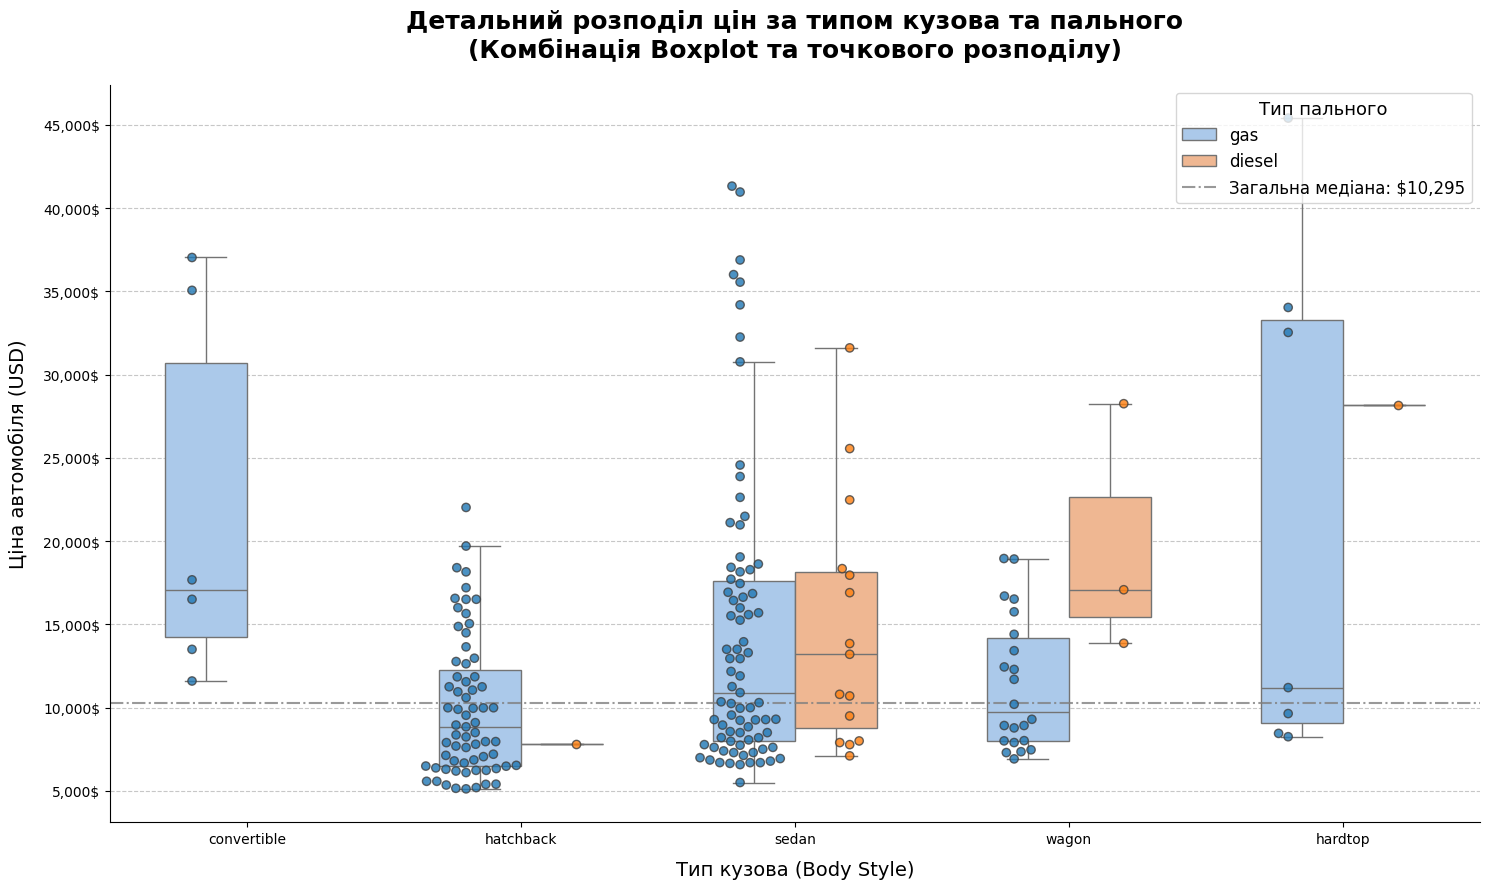

In [6]:
fig, ax = plt.subplots(figsize=(15, 9))

sns.boxplot(data=df, x='body-style', y='price', hue='fuel-type', 
            palette='pastel', width=0.6, showfliers=False, ax=ax)

sns.swarmplot(data=df, x='body-style', y='price', hue='fuel-type', 
              dodge=True, edgecolor='auto', linewidth=1, size=6, alpha=0.8, ax=ax)

global_median = df['price'].median()
ax.axhline(global_median, color='gray', linestyle='-.', linewidth=1.5, alpha=0.8, 
           label=f'Загальна медіана: ${global_median:,.0f}')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}$".format(int(x))))

ax.set_title("Детальний розподіл цін за типом кузова та пального\n(Комбінація Boxplot та точкового розподілу)", 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Тип кузова (Body Style)", fontsize=14, labelpad=10)
ax.set_ylabel("Ціна автомобіля (USD)", fontsize=14, labelpad=10)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2] + [handles[-1]], labels[:2] + [labels[-1]], 
          title="Тип пального", fontsize='12', title_fontsize='13', loc='upper right')

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 6. Теплова карта кореляції (Корисна інформація про датасет)
Для виконання пункту щодо побудови інших графіків, що розкривають корисну інформацію про датасет, побудовано теплову карту кореляції Пірсона для всіх числових ознак.

Для покращення читабельності застосовано маску, яка приховує верхню (дублюючу) частину матриці, залишаючи лише унікальні коефіцієнти взаємозв'язку. Це дозволяє швидко виявляти мультиколінеарність у даних.

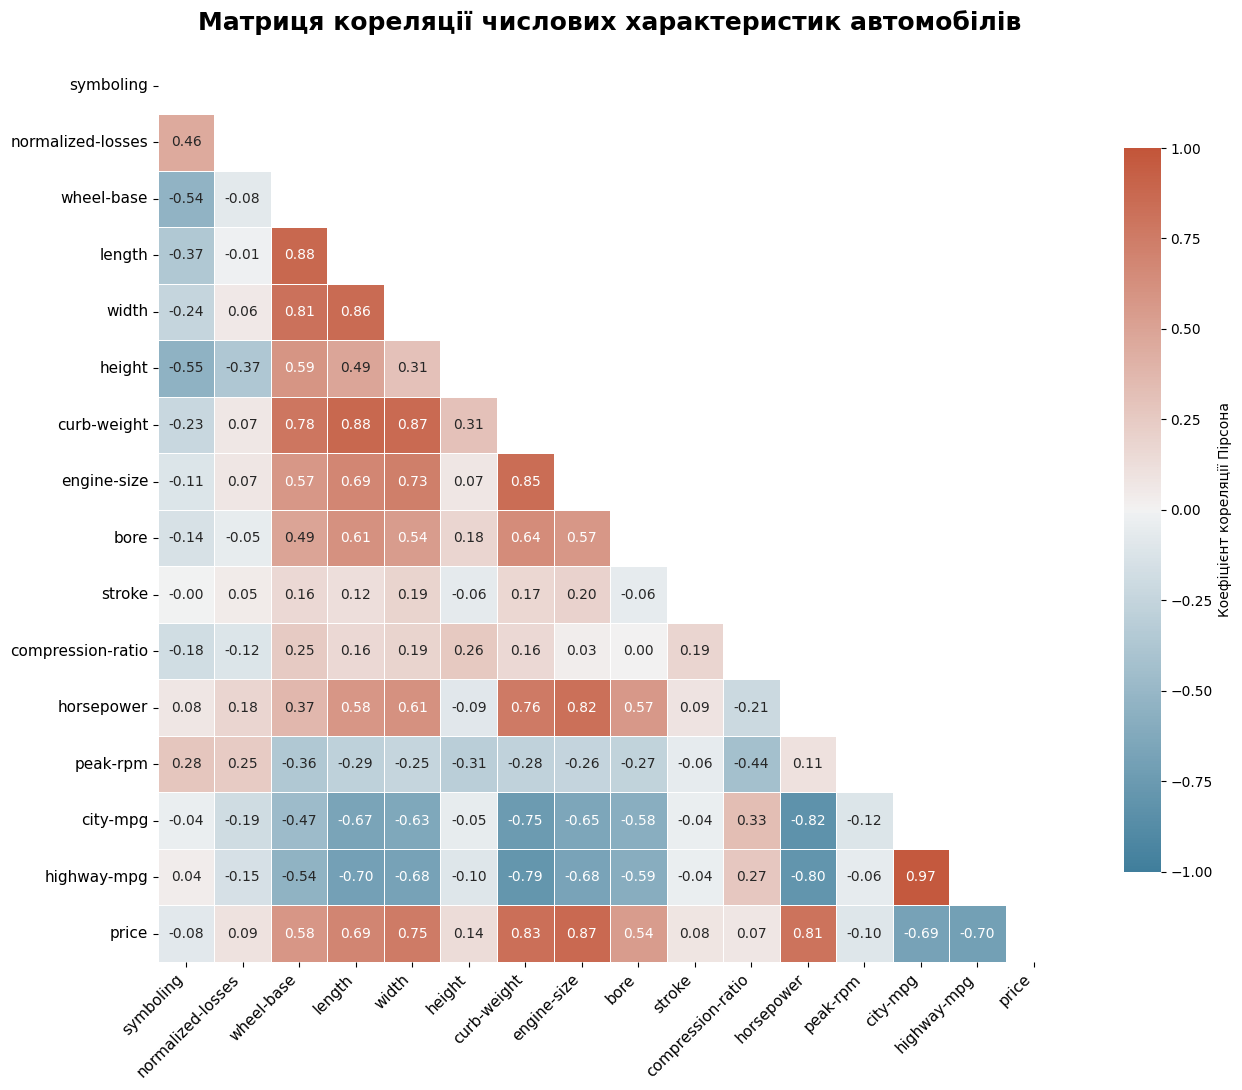

In [7]:
fig, ax = plt.subplots(figsize=(14, 11))

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1.0, vmin=-1.0, center=0,
            square=True, linewidths=.5, annot=True, fmt=".2f",
            annot_kws={"size": 10}, 
            cbar_kws={"shrink": .8, "label": "Коефіцієнт кореляції Пірсона"}, ax=ax)

ax.set_title("Матриця кореляції числових характеристик автомобілів", 
             fontsize=18, fontweight='bold', pad=20)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

### 7. Розподіл за марками автомобілів
Останній графік показує розподіл кількості представлених автомобілів у розрізі брендів. Діаграма відсортована за спаданням, а ТОП-3 найпопулярніші марки виділені кольором та забезпечені точними підписами даних (Data Labels) для швидкого зчитування інформації.

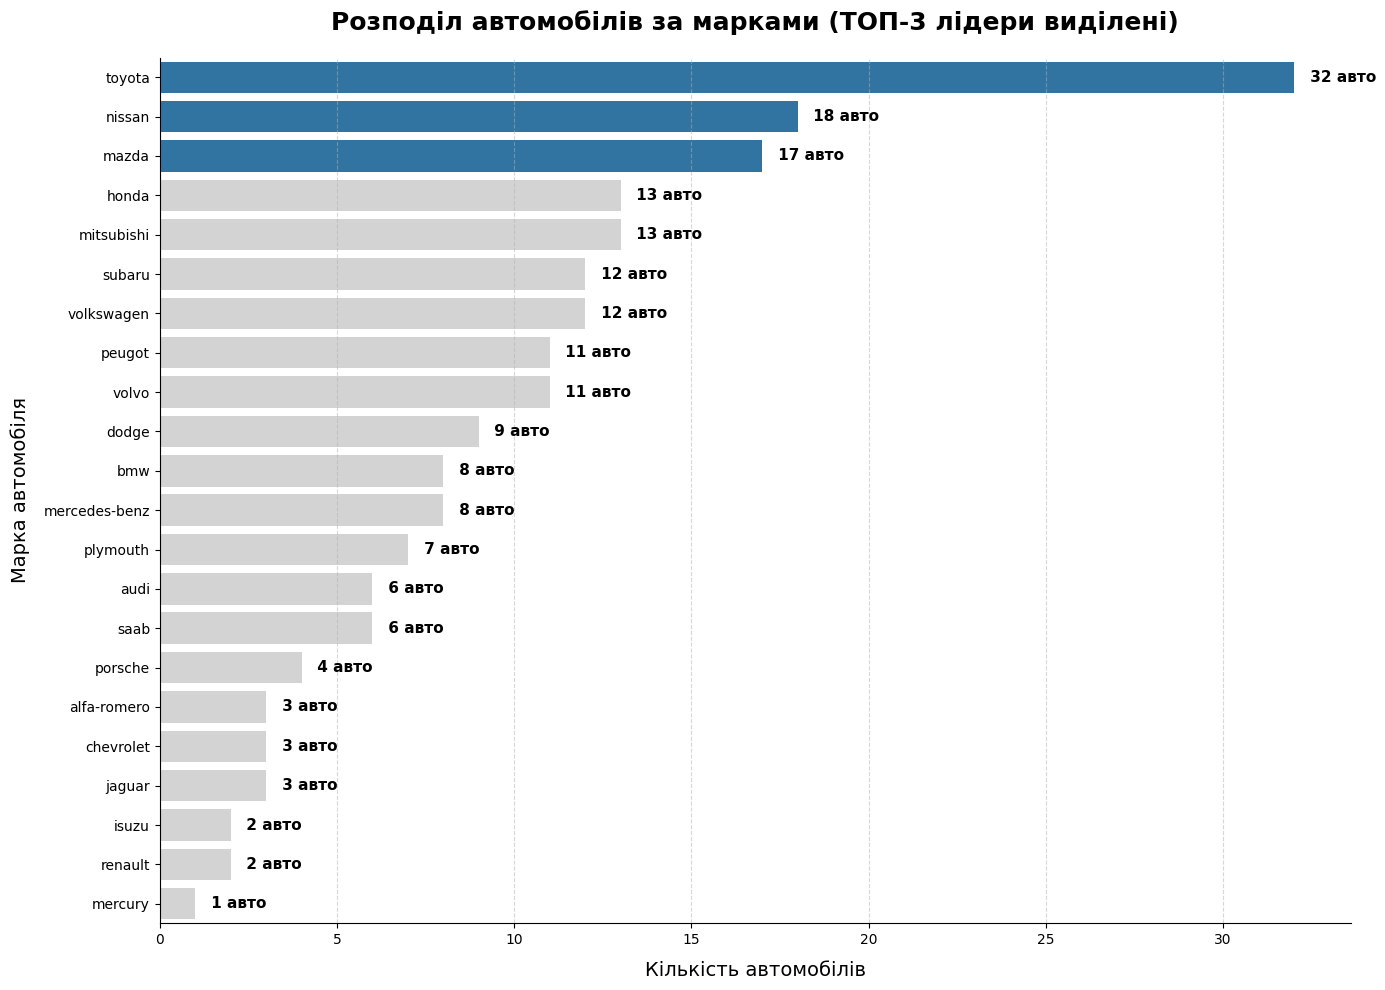

In [8]:
fig, ax = plt.subplots(figsize=(14, 10))

make_counts = df['make'].value_counts()

custom_palette = ['#1f77b4' if i < 3 else '#d3d3d3' for i in range(len(make_counts))]

sns.barplot(x=make_counts.values, y=make_counts.index, 
            hue=make_counts.index, palette=custom_palette, legend=False, ax=ax)

for i, v in enumerate(make_counts.values):
    ax.text(v + 0.3, i, f" {v} авто", color='black', va='center', 
            fontweight='bold', fontsize=11)

ax.set_title("Розподіл автомобілів за марками (ТОП-3 лідери виділені)", 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Кількість автомобілів", fontsize=14, labelpad=10)
ax.set_ylabel("Марка автомобіля", fontsize=14, labelpad=10)

ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.subplots_adjust(right=0.9)
plt.tight_layout()
plt.show()